<a href="https://colab.research.google.com/github/Nocte88/FDS-Project-1/blob/main/FDS_Project_LearnerNotebook_FullCode_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [2]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# read the data
df = pd.read_csv('/content/drive/MyDrive/MIT/Colab Notebooks/foodhub_order.csv')
# returns the first 5 rows
df.head()

Mounted at /content/drive


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# describes the shape of the dataframe by rows and columns
shape = df.shape
print(f"The DataFrame has {shape[0]} rows and {shape[1]} columns.")

The DataFrame has 1898 rows and 9 columns.


#### Observations:
This dataframe has 1898 rows corresponding to individual orders and 9 columns separating the order data into 9 categories.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
There are 1898 elements total for each category (column). One of the columns contains data type float, four of the nine columns are of data type integer, and four of the nine columns are of data type object. At first glance, the uniformity of available elements (1898 per column) suggests there are no missing value points.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# summary of missing values in the data set should there be any
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:

The figure above suggests there are no missing data values found in this data set.

Should we have found any missing values, there are a few treatment methods we could try to fill in the gaps.

Deletion is the removal of data from a data set, whether row-wise or column-wise, to rid of any cases where values are missing from the data set. This could lead to substantial data losses and is not always recommended. Imputation is another method, which utilizes the characteristics of the data set to fill in gaps where values are missing. For example, mean imputation would replace any missing numerical values with the mean or average of the values available in that column or row. These are only a couple examples of how we could treat data sets with missing values.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:

# describes characteristics of the data frame and displays them in a grid
describe_results = df.describe()
describe_results

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [ ]:
#pinpoints the minimum food preparation time
min_prep_time = describe_results.loc['min', 'food_preparation_time']

#pinpoints the maximum food preparation time
max_prep_time = describe_results.loc['max', 'food_preparation_time']

#pinpoints the average food preparation time
avg_prep_time = df['food_preparation_time'].mean()
avg_prep_time = round(avg_prep_time, 2)

#presenting target information together
print(f"The minimum time required for food preparation once an order is placed is {min_prep_time} minutes.")
print(f"The maximum time required for food preparation once an order is placed is {max_prep_time} minutes.")
print(f"The average time required for food preparation once an order is placed is {avg_prep_time} minutes.")

The minimum time required for food preparation once an order is placed is 20.0 minutes.
The maximum time required for food preparation once an order is placed is 35.0 minutes.
The average time required for food preparation once an order is placed is 27.37 minutes.


#### Observations:

The minimumum amount of time required for food preparation once an order is receieved is 20 minutes. The maximum amount of time is 35 minutes. The average amount of time required is approximately 27.37 minutes.


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# first check the value counts to determine if "Not Given" is represented
df['rating'].value_counts()


,count
rating,
Not given,736
5,588
4,386
3,188


In [ ]:
# checks the amount of orders that did not receive a rating and print a message
df_not_rated = (df['rating'] == 'Not given').sum()
print(f"There are {df_not_rated} orders that did not receive a rating.")


There are 736 orders that did not receive a rating.


#### Observations:
We find there are a
total of 736 entries that did not receive a rating. This can be a little misleading as, prior to targetting the "Not given" values rather than missing values, analysis displayed there were no missing data values. However, the "missing values" in this case are not simply missing, but are notated as "Not given" in terms of rating. Upon scanning the data in search of "Not given" ratings, we find there are 736 ratings with the value of "Not given".


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

### EDA - Order ID

In [ ]:
""" order_id is a unique identifier, instead of a distribution, we will
      look at the number of unique order_id values """

# Check the number of unique order_id values
num_unique_orders = df['order_id'].nunique()

print(f"The number of unique order IDs in the dataset is: {num_unique_orders}")

# checks if the number of unique orders matches the total number of rows,
# which would indicate no duplicate order entries
if num_unique_orders == len(df):
    print("This indicates that each row corresponds to a unique order.")
else:
    print("Warning: There might be duplicate order entries.")

The number of unique order IDs in the dataset is: 1898
This indicates that each row corresponds to a unique order.


### EDA - Customer ID

Top 10 most frequent customers (Customer ID and number of orders):


,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7
65009,7
276192,7
82041,7
115213,6


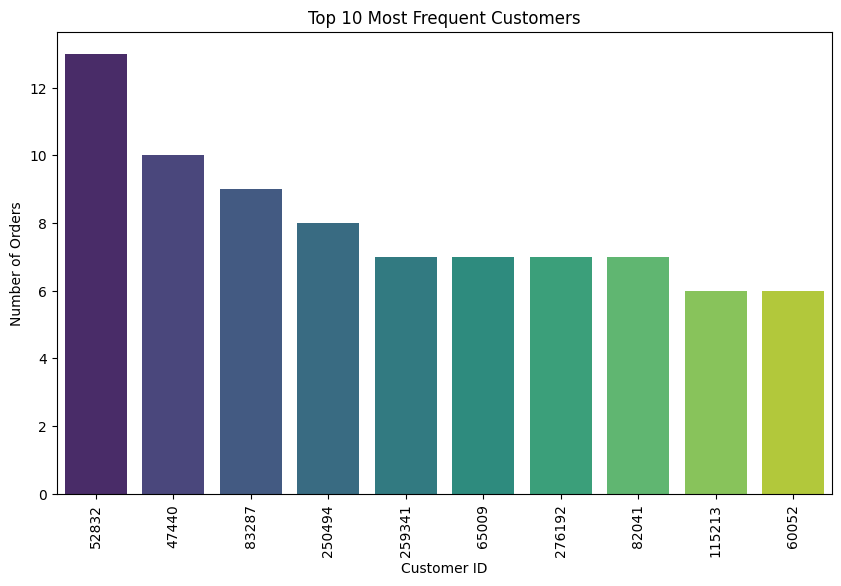

In [ ]:
""" customer_id is a unique identifier, instead of a distribution, we will
      look at the number of unique customer_id values and see if
      there are any duplicates """
# Calculate the top 10 most active customer IDs
customer_order_counts = df['customer_id'].value_counts().head(10)

# Display the top 10 most active customer IDs

print("Top 10 most frequent customers (Customer ID and number of orders):")
display(customer_order_counts.head(10))

# looks at the distribution of the number of orders per customer
plt.figure(figsize=(10, 6))
sns.barplot(x=customer_order_counts.index.astype(str), y=customer_order_counts.values, hue=customer_order_counts.index.astype(str), legend=False, palette='viridis')
plt.xlabel('Customer ID')
plt.ylabel('Number of Orders')
plt.title('Top 10 Most Frequent Customers')
plt.xticks(rotation=90)
plt.show()

### EDA - Restaurant Name

Top 10 most popular restaurants (Restaurant Name and number of orders):


,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
RedFarm Broadway,59
RedFarm Hudson,55
TAO,49
Han Dynasty,46


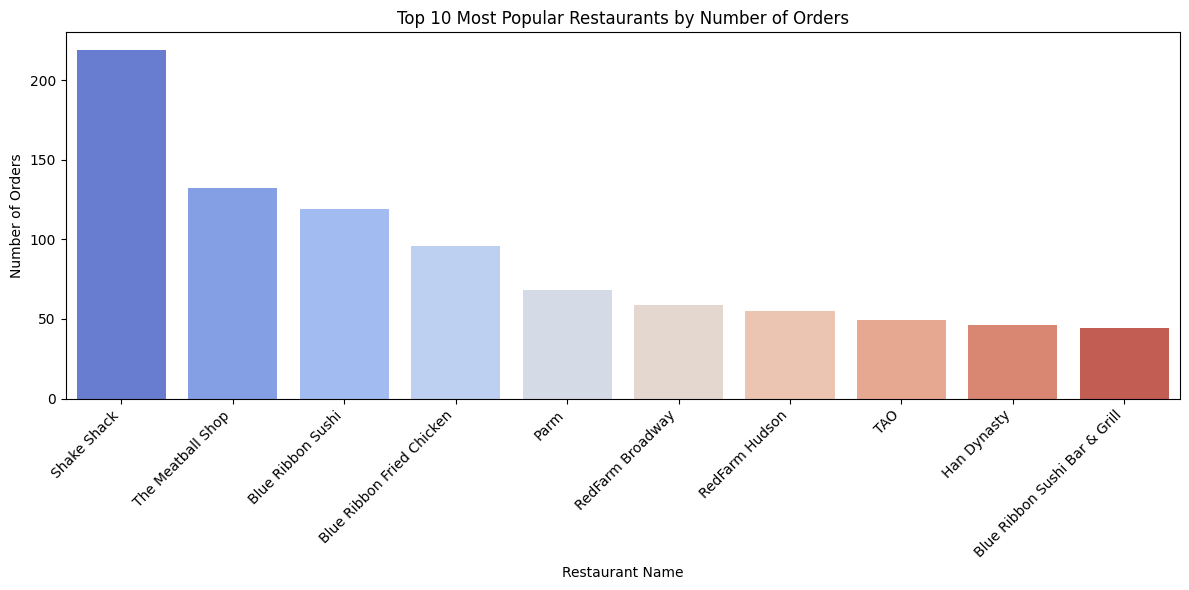

In [ ]:
# Calculate the frequency of each restaurant_name
restaurant_counts = df['restaurant_name'].value_counts()

print("Top 10 most popular restaurants (Restaurant Name and number of orders):")
display(restaurant_counts.head(10))

# Visualize the highest frequency restaurants
plt.figure(figsize=(12, 6))
sns.barplot(x=restaurant_counts.head(10).index, y=restaurant_counts.head(10).values, hue=restaurant_counts.head(10).index, legend=False, palette='coolwarm')
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Orders')
plt.title('Top 10 Most Popular Restaurants by Number of Orders')
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### EDA - Cuisine Type

The number of unique cuisine types in the dataset is: 14


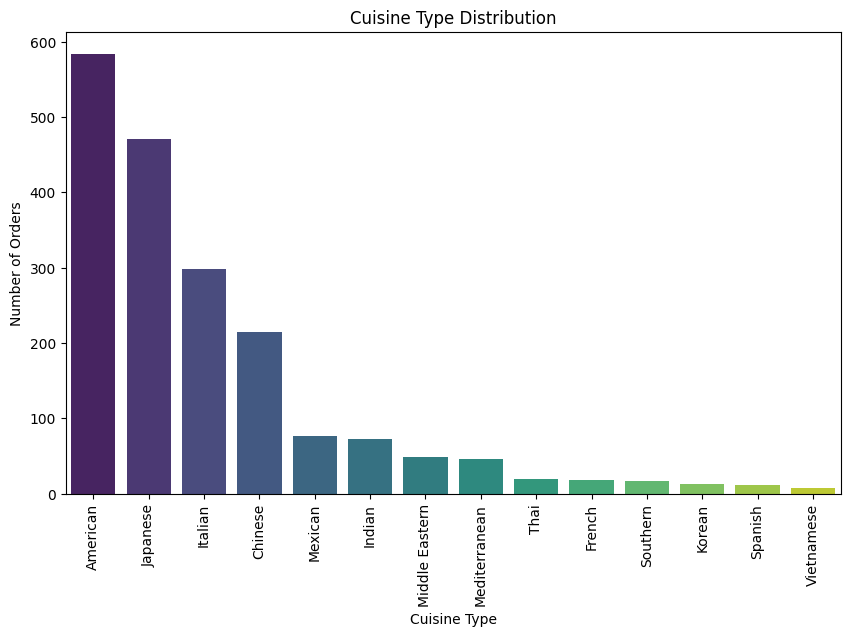

In [ ]:
#checking total categories of cuisine type and displaying message
num_unique_cuisines = df['cuisine_type'].nunique()
print(f"The number of unique cuisine types in the dataset is: {num_unique_cuisines}")

#visualizing types of cuisine and their frequency
cuisine_counts = df['cuisine_type'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=cuisine_counts.index, y=cuisine_counts.values, hue=cuisine_counts.index, legend=False, palette='viridis')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Orders')
plt.title('Cuisine Type Distribution')
plt.xticks(rotation=90)
plt.show()

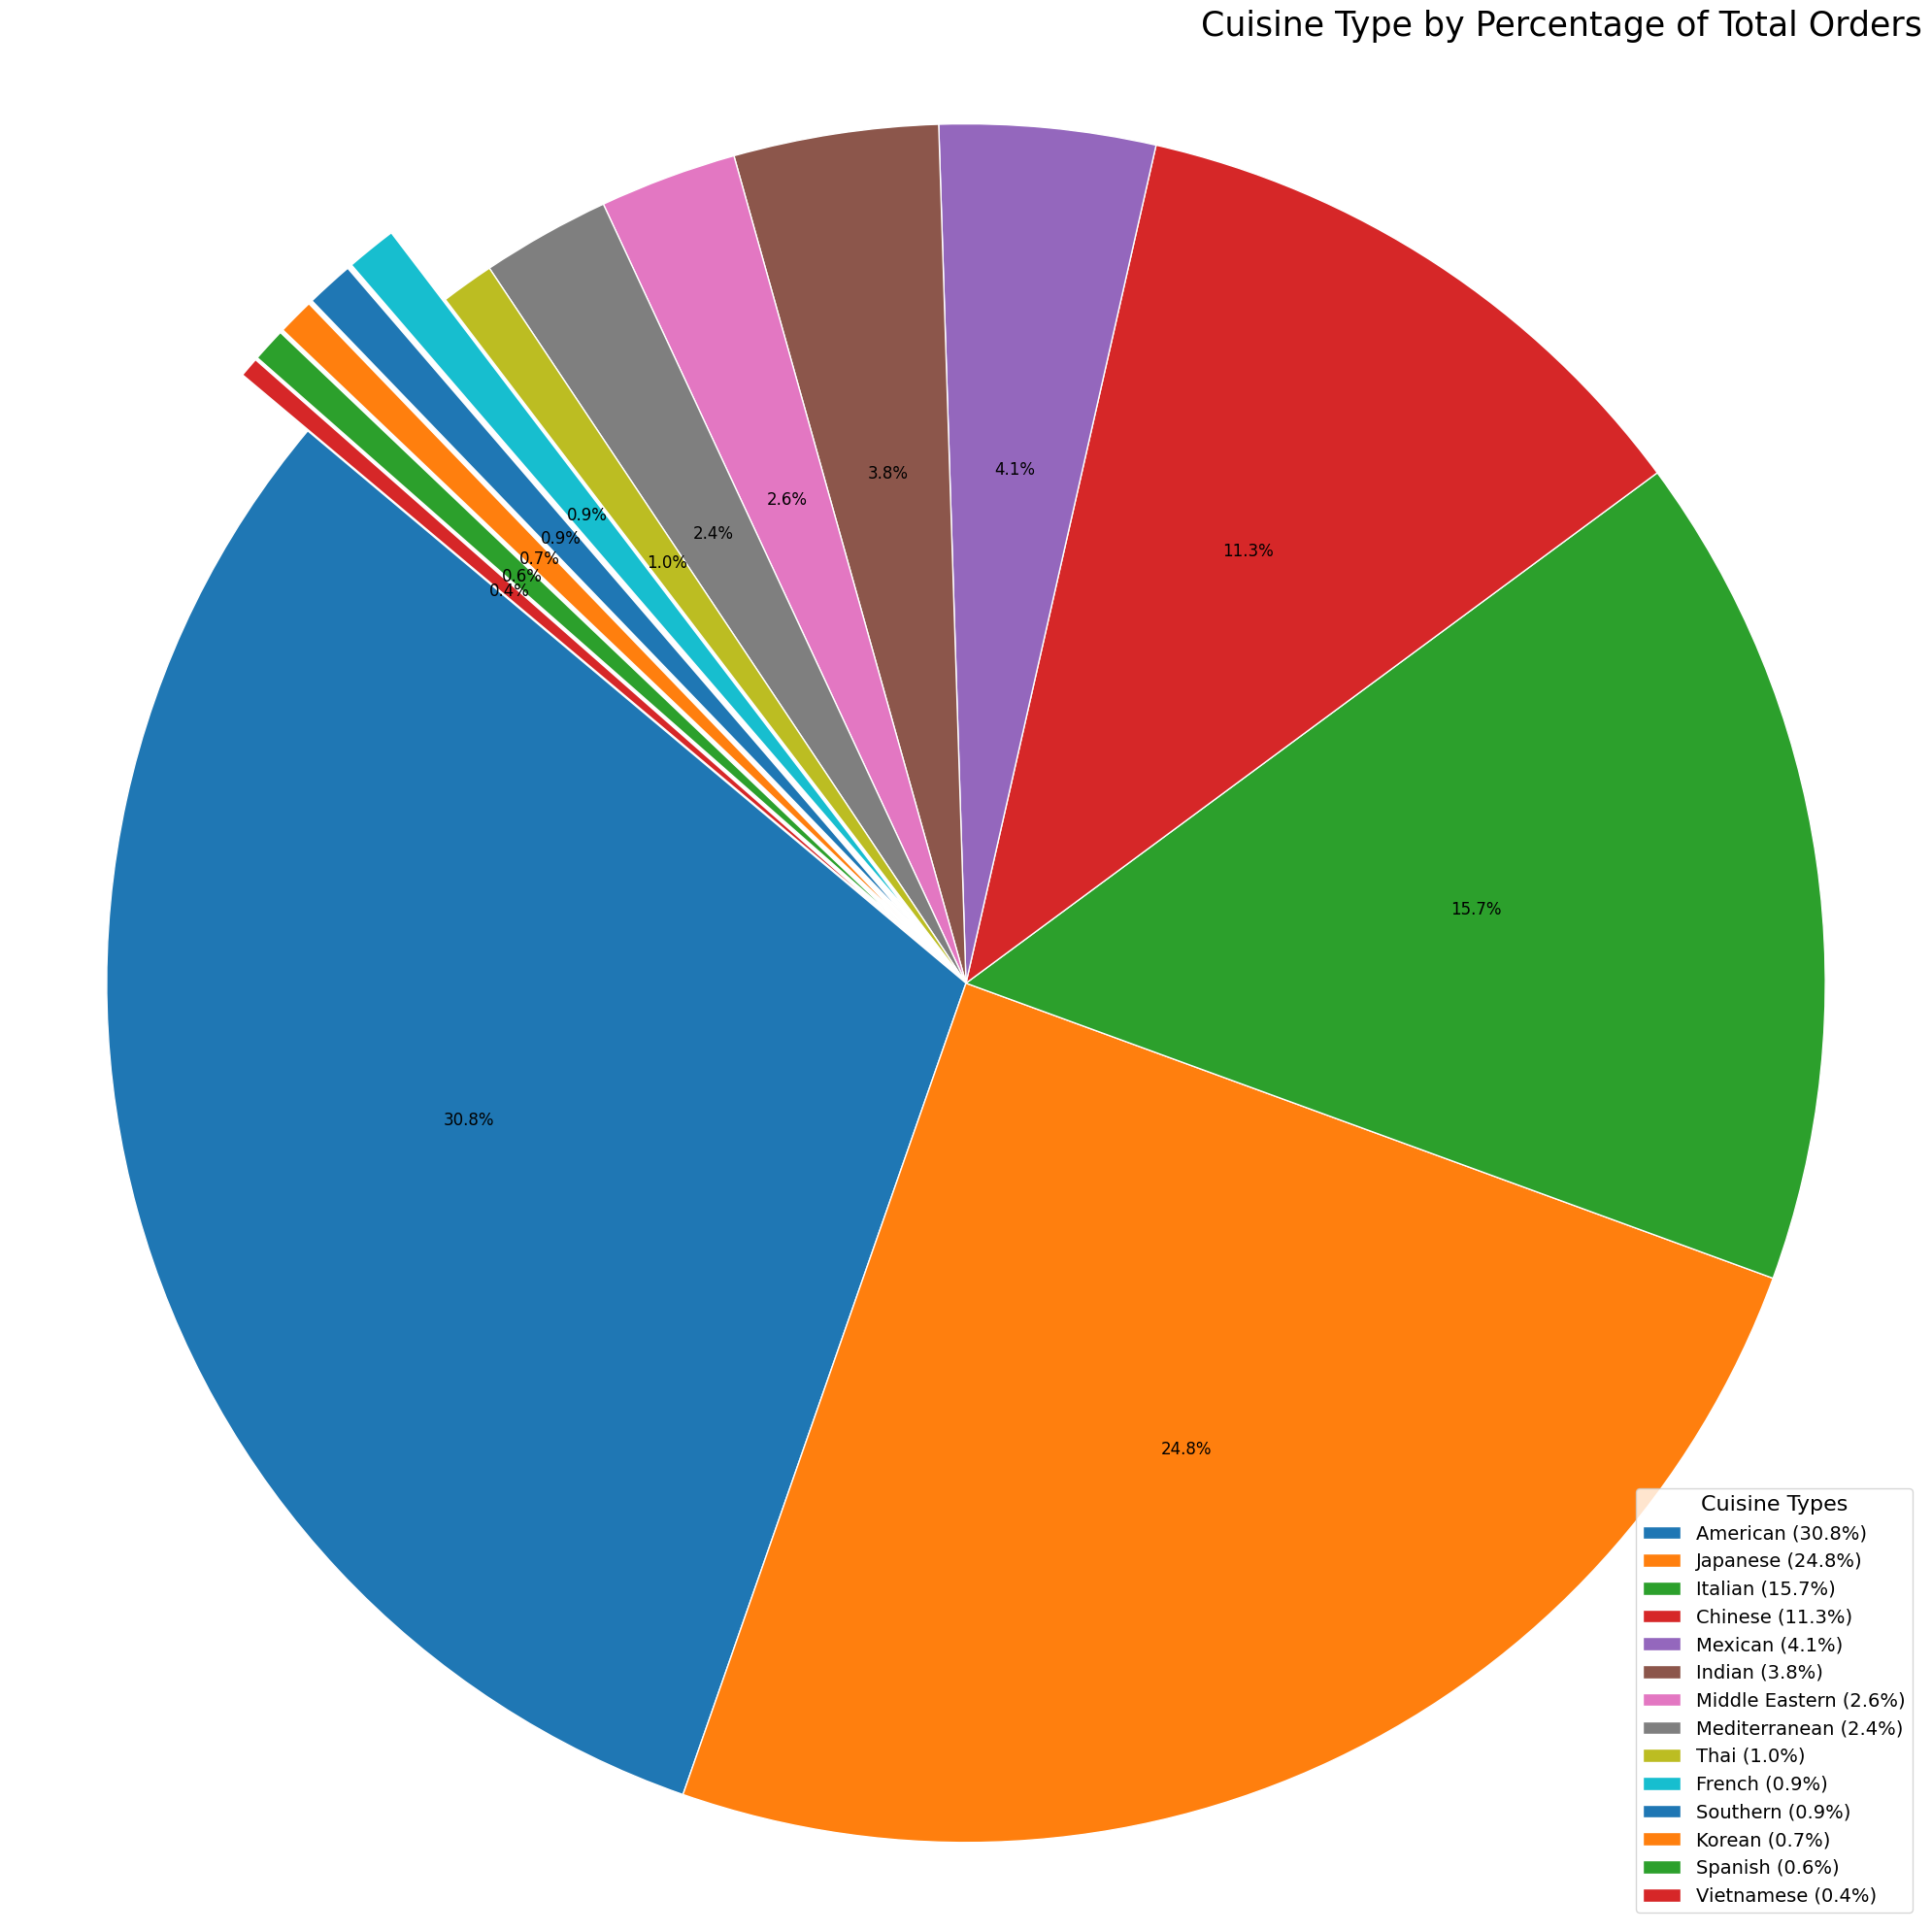

In [ ]:
# Calculate percentages to determine which slices to explode
total_orders = df['cuisine_type'].value_counts().sum()
percentages = (df['cuisine_type'].value_counts() / total_orders) * 100

# Get the indices of the 5 smallest percentages
smallest_5_indices = percentages.nsmallest(5).index

# Create the explode list. Initialize with zeros.
explode = [0] * len(percentages)

# Set explode for the 5 smallest percentages
# We need to iterate through the original order of cuisine_counts.index
# and check if each cuisine type is in smallest_5_indices.
for i, cuisine in enumerate(cuisine_counts.index):
    if cuisine in smallest_5_indices:
        explode[i] = 0.1

# Create figure and axes
fig, ax = plt.subplots(figsize=(20, 20))

# pie chart showing percentage of total orders each cuisine type holds
wedges, texts, autotexts = ax.pie(cuisine_counts.values,
                                  autopct='%1.1f%%',
                                  startangle=140,
                                  explode=explode,
                                  textprops={'fontsize': 12},
                                  wedgeprops=dict(edgecolor='w'))

# Add title
ax.set_title('Cuisine Type by Percentage of Total Orders', fontsize=25, loc='right')

# Equal aspect ratio ensures that pie is drawn as a circle.
ax.axis('equal')

# Shrink the pie chart slightly to make room for the legend
box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1, box.width, box.height * 0.9])

# Create a legend and place it in the bottom right of the figure
ax.legend(wedges, [f'{label} ({p:.1f}%)' for label, p in zip(cuisine_counts.index, percentages)],
          title="Cuisine Types",
          loc="lower right",
          bbox_to_anchor=(1, 0), # Place the legend's lower right corner at the figure's lower right corner
          fontsize=14,
          title_fontsize=16)

plt.tight_layout() # Automatically adjust subplot parameters for a tight layout
plt.show()

### EDA - Cost of the Order

In [3]:
# finding total order cost of given data set
total_cost = df['cost_of_the_order'].sum()
print(f"The total cost of all orders summed is ${total_cost}.")

The total cost of all orders summed is $31314.82.


In [ ]:
# finding percentage of total order is attributed to each cuisine type
# column two is to be read in percentages rounded to 2nd decimal
cuisine_cost = df.groupby('cuisine_type')['cost_of_the_order'].sum()
cuisine_cost_percentage = (cuisine_cost / total_cost) * 100
cuisine_cost_percentage = cuisine_cost_percentage.round(2)
cuisine_cost_percentage

,cost_of_the_order
cuisine_type,
American,30.44
Chinese,11.19
French,1.14
Indian,3.94
Italian,15.62
Japanese,24.47
Korean,0.58
Mediterranean,2.27
Mexican,4.16


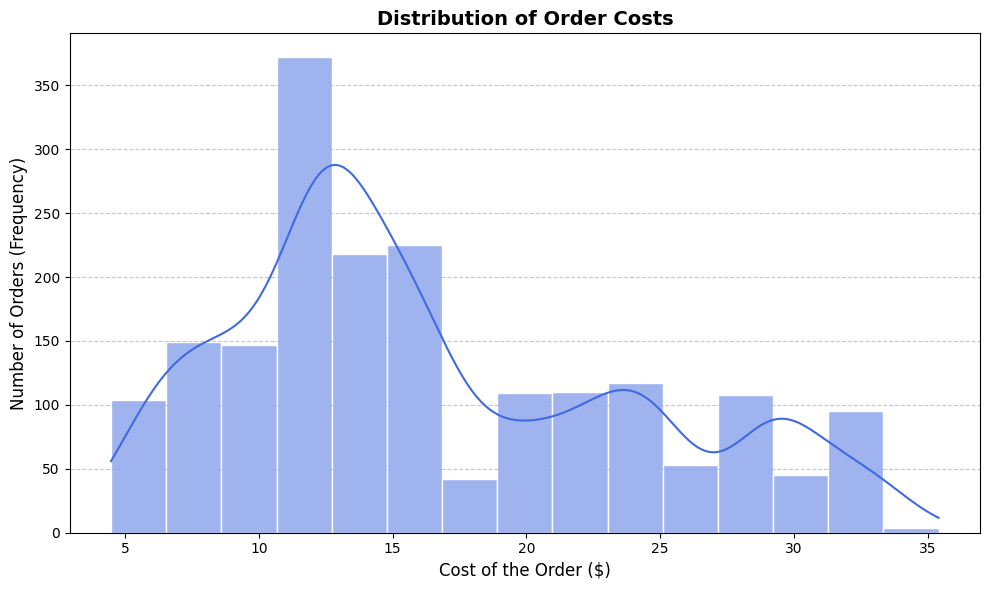

In [ ]:
# plot 1: histogram
# for better visualisation of the data and improved understanding of following box plot
plt.figure(figsize=(10, 6)) # Increased figure size for better readability
sns.histplot(data=df, x='cost_of_the_order', kde=True,
             binwidth=2, # groups data into clean $2 brackets
             color='royalblue',
             edgecolor='white') # separates bars clearly

plt.xlabel('Cost of the Order ($)', fontsize=12)
plt.ylabel('Number of Orders (Frequency)', fontsize=12)
plt.title('Distribution of Order Costs', fontsize=14, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7) # adds a subtle grid
plt.tight_layout() # Adjusts the layout to prevent labels from overlapping
plt.show()

### This figure suggests that the bulk of the orders (frequency) occur in the lower cost bracket of the data set.

We need to check and see if there are any outliers that could be affecting the visualization of the data.

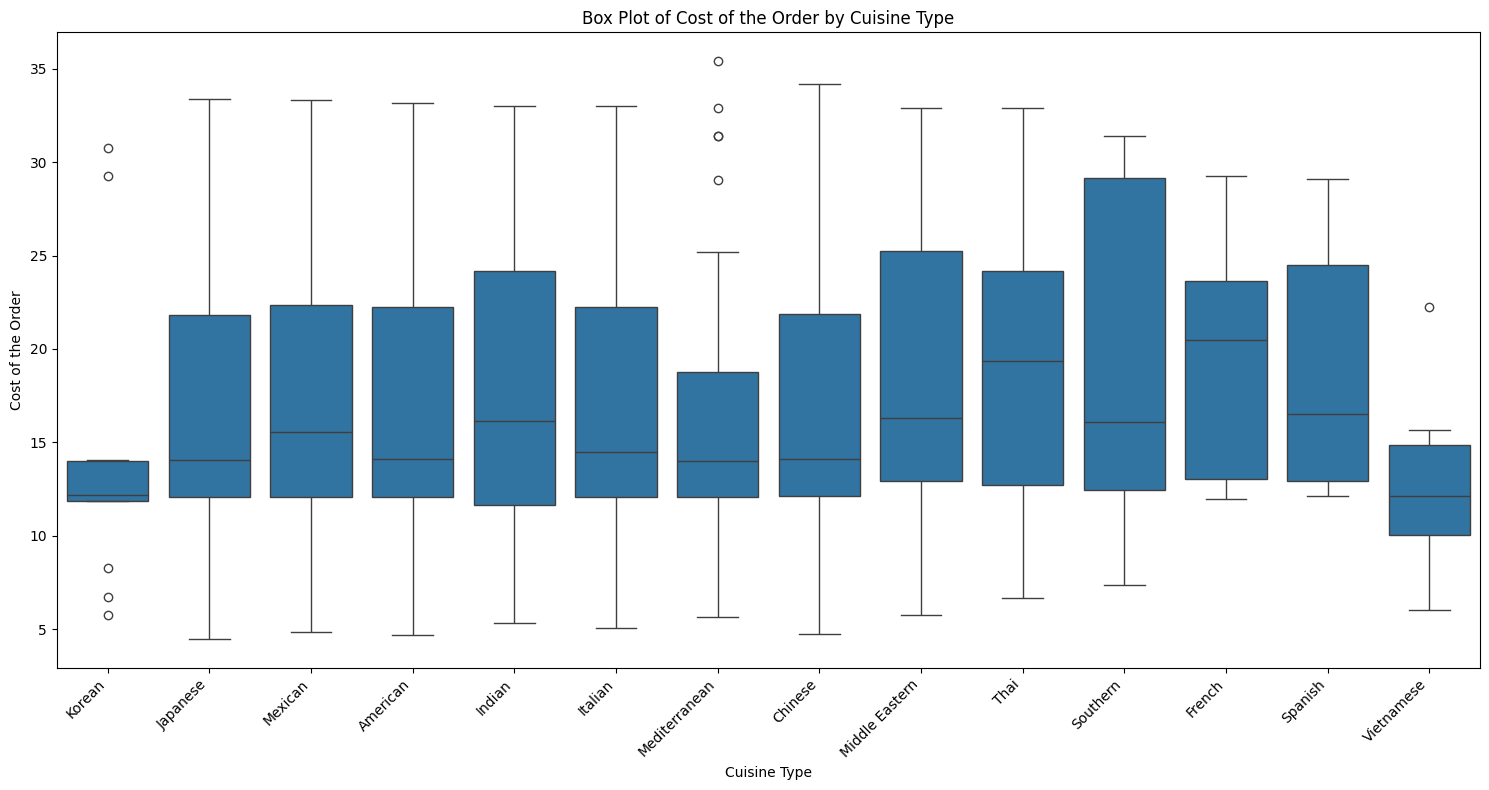

In [ ]:
# plotting cost_of_the_order data in box plot format for better visualisation
# the goal is to identify any outliers which may skew the data in terms of how much
# each order's cost relates to the total cost of orders available in the data set

#plot 2: box plot
plt.figure(figsize=(15, 8)) # Increased figure size for better readability
sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of the Order')
plt.title('Box Plot of Cost of the Order by Cuisine Type')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better visibility
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### The above figure suggests there are some outliers that could be causing the cost of Mediterranean food to seem higher than it may actually be and may not be representative of the population. We also see there are some outliers bringing the average cost of Korean food down which could be misrepresentative of the population.

### EDA - Day of the Week (Weekend / Weekday)

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [4]:
# shows top 5 restaurants in terms of number of orders received
top_5_restaurants = df['restaurant_name'].value_counts().head(5)
top_5_restaurants

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


In [5]:
# shows the percentage of the top 5 restaurants compared to the total orders received
top_5_restaurants_percentage = (top_5_restaurants / len(df)) * 100
top_5_restaurants_percentage = top_5_restaurants_percentage.round(2)
top_5_restaurants_percentage

,count
restaurant_name,
Shake Shack,11.54
The Meatball Shop,6.95
Blue Ribbon Sushi,6.27
Blue Ribbon Fried Chicken,5.06
Parm,3.58


#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [11]:
# filtering data to get top 5 cuisine types for weekends and weekdays
weekend_cuisines = df[df["day_of_the_week"]== "Weekend"]["cuisine_type"].value_counts().head(5)
weekday_cuisines = df[df["day_of_the_week"]== "Weekday"]["cuisine_type"].value_counts().head(5)
print("Top 5 Cuisine Types for Weekends:")
print(weekend_cuisines)
print("\nTop 5 Cuisine Types for Weekdays:")
print(weekday_cuisines)

Top 5 Cuisine Types for Weekends:
cuisine_type
American    415
Japanese    335
Italian     207
Chinese     163
Mexican      53
Name: count, dtype: int64

Top 5 Cuisine Types for Weekdays:
cuisine_type
American    169
Japanese    135
Italian      91
Chinese      52
Mexican      24
Name: count, dtype: int64


In [13]:
# calculates percentages for deeper insights
weekend_cuisines_percentage = (df[df["day_of_the_week"] == "Weekend"]["cuisine_type"].value_counts(normalize=True).head(5) * 100).round(2)
weekday_cuisines_percentage = (df[df["day_of_the_week"] == "Weekday"]["cuisine_type"].value_counts(normalize=True).head(5) * 100).round(2)
print("Percentage of Top 5 Cuisine Types for Weekends:")
print(weekend_cuisines_percentage)
print("\nPercentage of Top 5 Cuisine Types for Weekdays:")
print(weekday_cuisines_percentage)


Percentage of Top 5 Cuisine Types for Weekends:
cuisine_type
American    30.72
Japanese    24.80
Italian     15.32
Chinese     12.07
Mexican      3.92
Name: proportion, dtype: float64

Percentage of Top 5 Cuisine Types for Weekdays:
cuisine_type
American    30.90
Japanese    24.68
Italian     16.64
Chinese      9.51
Mexican      4.39
Name: proportion, dtype: float64


#### Observations:
The analysis above suggests American style food is most popular on both weekends and weekdays in this data set.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [15]:
# calculates the percentage of orders that cost more than 20 dollars out of the total number of orders
orders_above_20 = df[df['cost_of_the_order'] > 20]
percentage_above_20 = (len(orders_above_20) / len(df)) * 100
percentage_above_20 = round(percentage_above_20, 2)
print(f"The percentage of orders that cost more than $20 is {percentage_above_20}%.")

The percentage of orders that cost more than $20 is 29.24%.


#### Observations:
The analysis above shows that approximately 29.2% of total orders in the data set cost more than 20 dollars. In other words, less than 1/3 of the total orders cost more than 20 dollars.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [16]:
# calculates the average order delivery time out of the total orders received
average_delivery_time = df['delivery_time'].mean()
average_delivery_time = round(average_delivery_time, 2)
print(f"The average order delivery time is {average_delivery_time} minutes.")

The average order delivery time is 24.16 minutes.


#### Observations:
The average order delivery time is roughly 24.2 minutes.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [20]:
# finds the top 3 most frequent customers to FoodHub in general and displays a message
top_3_customers = df['customer_id'].value_counts().head(3)
print("The top 3 most frequent customers are:")
print(top_3_customers)

# uses the customer_ids located in the previous code to calculate how many total orders each customer has placed and displays a message
customer_1 = df[df['customer_id'] == top_3_customers.index[0]]
customer_2 = df[df['customer_id'] == top_3_customers.index[1]]
customer_3 = df[df['customer_id'] == top_3_customers.index[2]]
print(f"\nCustomer {top_3_customers.index[0]} has placed {len(customer_1)} orders.")
print(f"Customer {top_3_customers.index[1]} has placed {len(customer_2)} orders.")
print(f"Customer {top_3_customers.index[2]} has placed {len(customer_3)} orders.")


The top 3 most frequent customers are:
customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

Customer 52832 has placed 13 orders.
Customer 47440 has placed 10 orders.
Customer 83287 has placed 9 orders.


#### Observations:

According to the analysis above, the top 3 customers in the data set in terms of order frequency are customers 52832, 47440, and 83287. Thus, the 20% discount vouchers for the top 3 customers of FoodHub should go to these customers.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


In [ ]:
# Write the code here

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [29]:
# finds all restaurants with a rating count of more than 50
# filters out the "Not given" ratings and converts the rating column to numeric values
df_rated = df[df['rating'] != 'Not given'].copy()
df_rated['rating'] = pd.to_numeric(df_rated['rating'])


# groups restaurants and calculates the count of ratings
restaurant_ratings = df_rated.groupby('restaurant_name').agg({'rating': ['count', 'mean']})
restaurant_ratings.columns = ['rating_count', 'average_rating']

# filters out restaurants with a rating count of more than 50 and an average rating greater than 4
restaurants_with_offer = restaurant_ratings[(restaurant_ratings['rating_count'] > 50) & (restaurant_ratings['average_rating'] > 4)]
print("Restaurants fulfilling the condition to get the promotional offer:")

#displays results
#print("Restaurants fulfilling the condition to get the promotional offer:")
print(restaurants_with_offer)


Restaurants fulfilling the condition to get the promotional offer:
                           rating_count  average_rating
restaurant_name                                        
Blue Ribbon Fried Chicken            64        4.328125
Blue Ribbon Sushi                    73        4.219178
Shake Shack                         133        4.278195
The Meatball Shop                    84        4.511905


#### Observations:


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Write the code here

#### Observations:


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Write the code here

#### Observations:


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here

#### Observations:


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  

### Recommendations:

*  

---